In [2]:
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from skimage.color import label2rgb
import csv


base_dir = Path.cwd()
print("Base dir:", base_dir)

sam_dir = base_dir / "cellpose_sam_results"
manual_dir = base_dir / "manual_segmentation_masks"
out_csv = base_dir / "sam_vs_manual_comparison.csv"

print("SAM dir exists:", sam_dir.exists(), sam_dir)
print("Manual dir exists:", manual_dir.exists(), manual_dir)

Base dir: /scratch/user/s4906996/Cellpose SAM
SAM dir exists: True /scratch/user/s4906996/Cellpose SAM/cellpose_sam_results
Manual dir exists: True /scratch/user/s4906996/Cellpose SAM/manual_segmentation_masks


In [3]:
from pathlib import Path
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import label2rgb
import csv

results_dir = base_dir / "sam_manual_comparison_results"
results_dir.mkdir(exist_ok=True)

print("Results folder:", results_dir)

Results folder: /scratch/user/s4906996/Cellpose SAM/sam_manual_comparison_results


In [4]:
sam_files = sorted(sam_dir.glob("*_sam_masks.tif*"))
manual_files = sorted(manual_dir.glob("*_mask.tif*"))

def sam_base(fp):
    name = fp.name
    name = name.replace("_sam_masks.tiff", "")
    name = name.replace("_sam_masks.tif", "")
    return name

def manual_base(fp):
    name = fp.name
    name = name.replace(" 2_mask.tiff", "")
    name = name.replace(" 2_mask.tif", "")
    name = name.replace("_mask.tiff", "")
    name = name.replace("_mask.tif", "")
    return name

manual_map = {manual_base(f): f for f in manual_files}

print("SAM files:", len(sam_files))
print("Manual files:", len(manual_files))

SAM files: 22
Manual files: 16


In [5]:
#METRICS FUNCTION 


def compute_metrics(sam_masks, manual_masks):
    sam_bin = sam_masks > 0
    manual_bin = manual_masks > 0

    intersection = np.logical_and(sam_bin, manual_bin).sum()
    union = np.logical_or(sam_bin, manual_bin).sum()

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (sam_bin.sum() + manual_bin.sum() + 1e-8)

    return iou, dice, sam_bin, manual_bin

614399S2D20250113 | SAM cells=21 | Manual cells=21 | IoU=0.4674 | Dice=0.6370


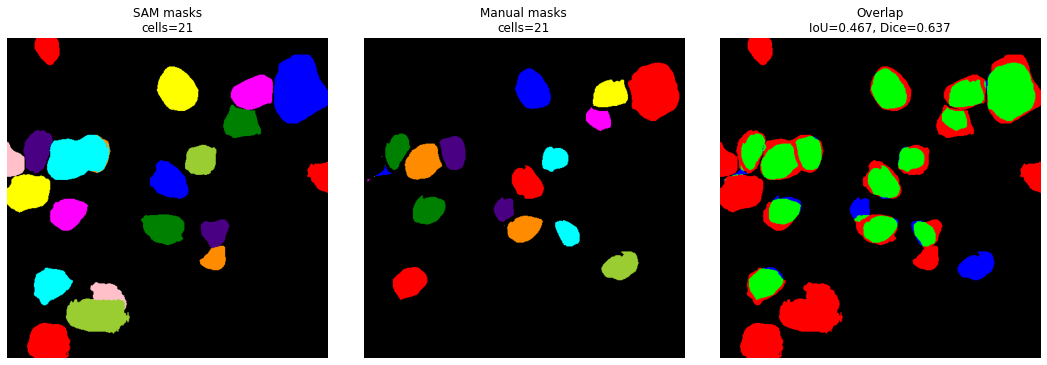

614399s1d120250113 | SAM cells=31 | Manual cells=27 | IoU=0.3595 | Dice=0.5289


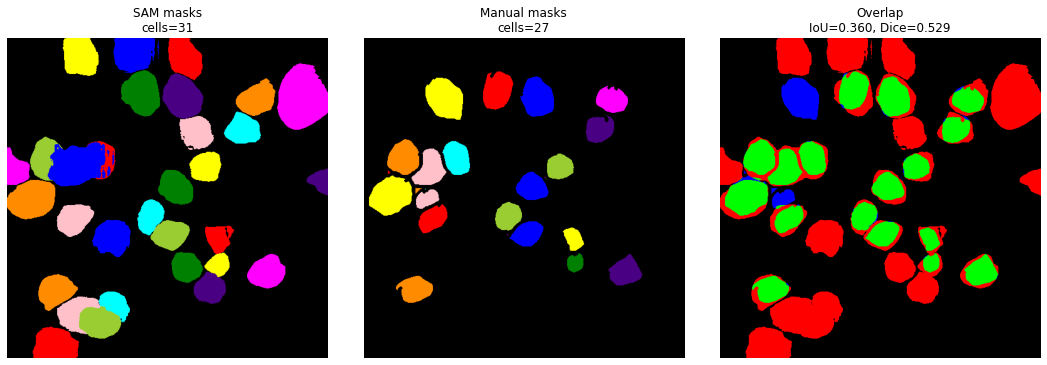

614399s1d20241213 | SAM cells=36 | Manual cells=33 | IoU=0.5085 | Dice=0.6741


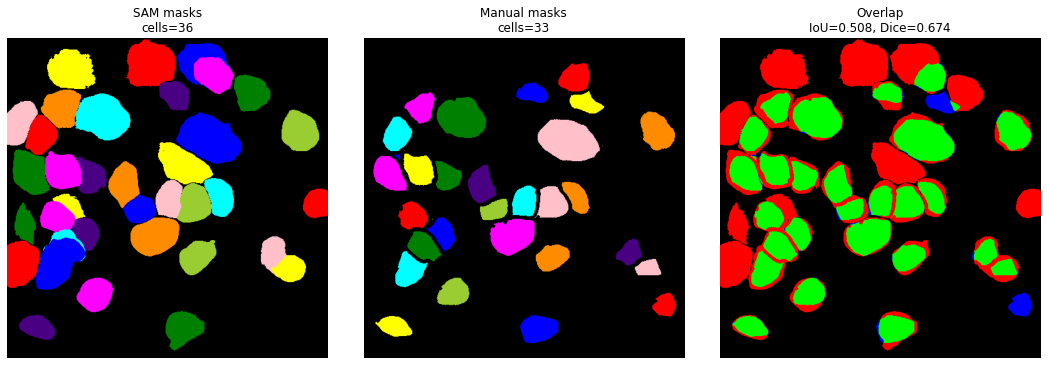

614399s1d20250108 | SAM cells=24 | Manual cells=22 | IoU=0.5066 | Dice=0.6725


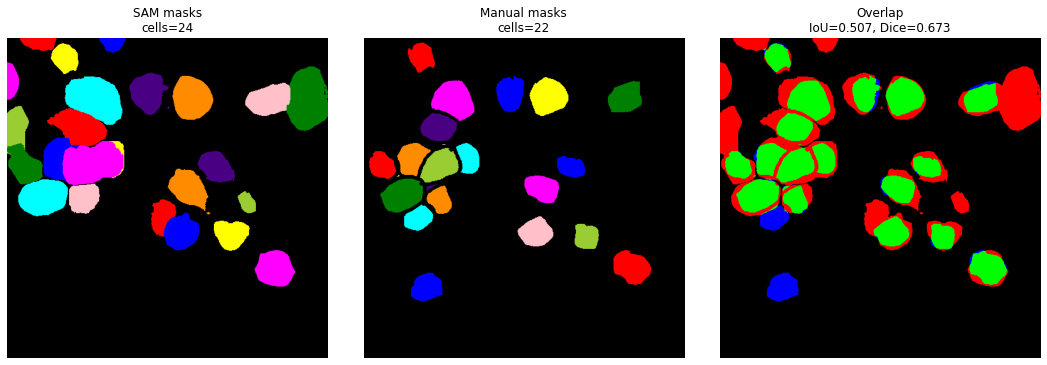

614400s1d20241218 | SAM cells=33 | Manual cells=20 | IoU=0.3611 | Dice=0.5306


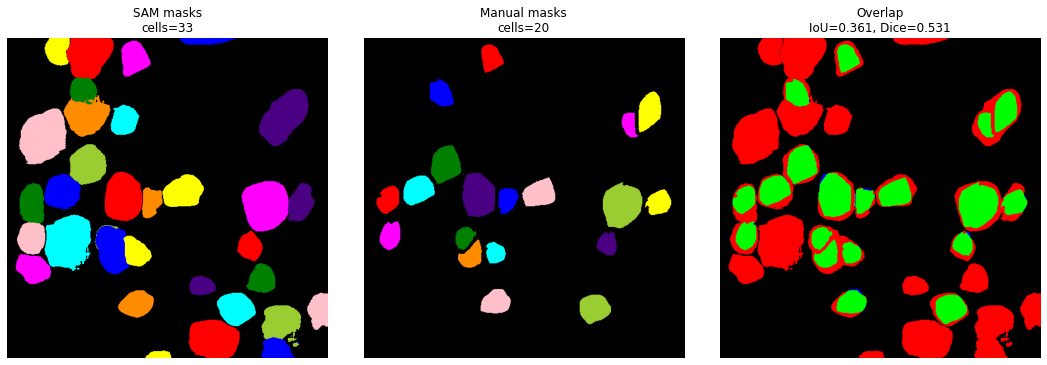

614400s1d20250108 | SAM cells=32 | Manual cells=32 | IoU=0.4521 | Dice=0.6227


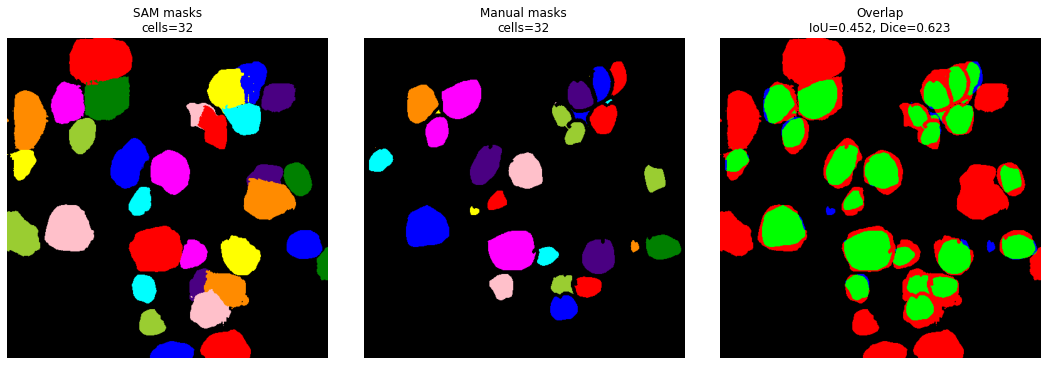

614401s1d20250114 | SAM cells=37 | Manual cells=34 | IoU=0.4872 | Dice=0.6552


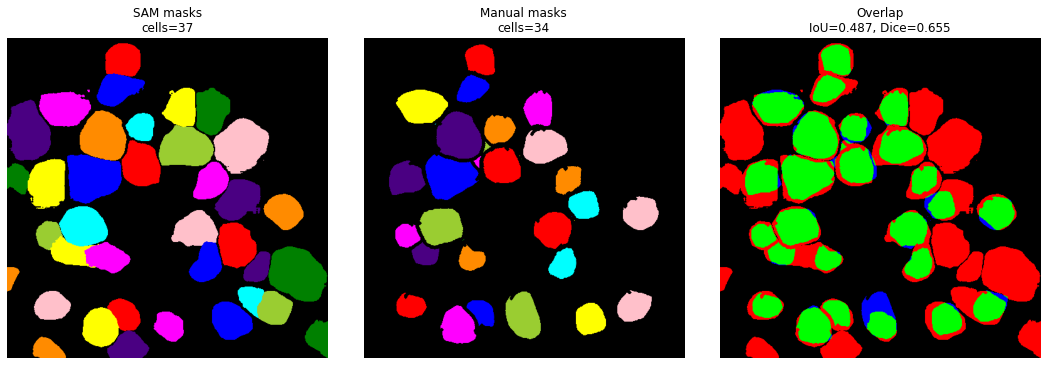

614401s1d20250414 | SAM cells=31 | Manual cells=26 | IoU=0.5340 | Dice=0.6962


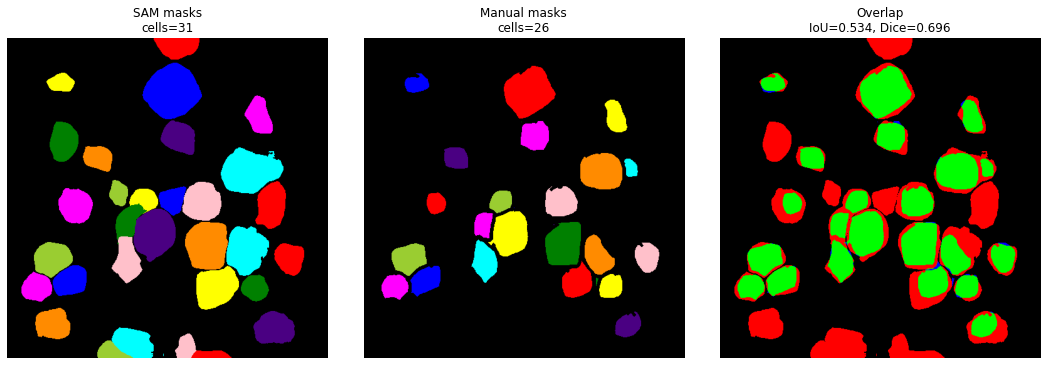

614404s1d20250115 | SAM cells=16 | Manual cells=19 | IoU=0.4429 | Dice=0.6139


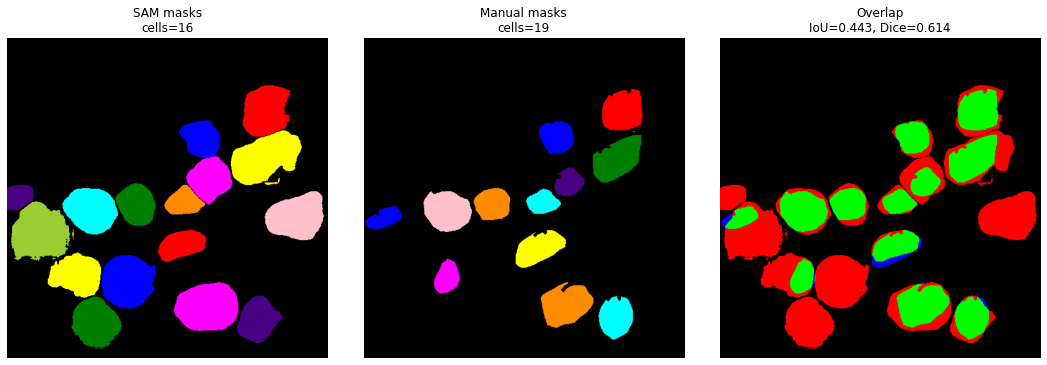

No manual match for: 671461s1d20250728_sam_masks.tif
No manual match for: 671462s1d20250728_sam_masks.tif
No manual match for: 671463s1d20250701_sam_masks.tif
No manual match for: 671463s2d20250701_sam_masks.tif
No manual match for: 671463s2d20250707_sam_masks.tif
No manual match for: 671480s1d20250325_sam_masks.tif
671480s1d20250709 | SAM cells=60 | Manual cells=43 | IoU=0.4877 | Dice=0.6556


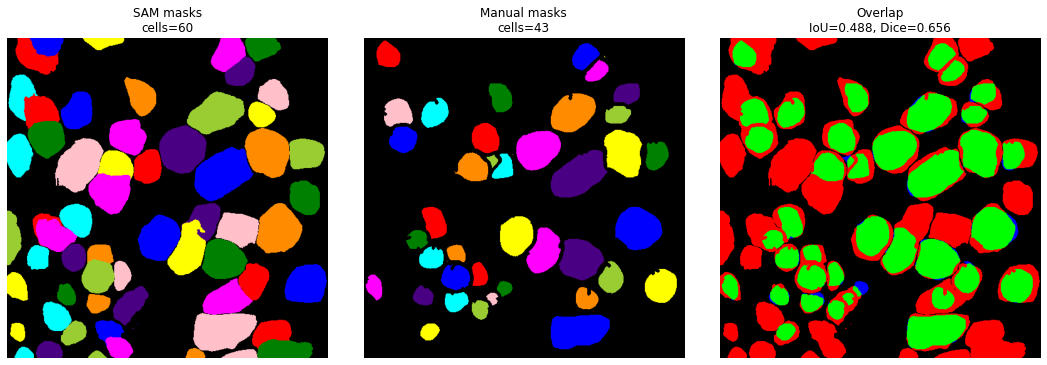

671481s1d20250326 | SAM cells=35 | Manual cells=27 | IoU=0.4002 | Dice=0.5716


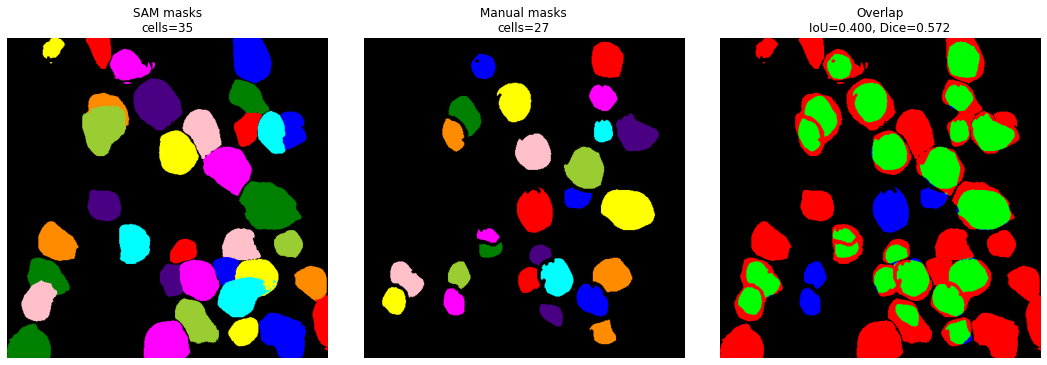

671482s1d20250218 | SAM cells=47 | Manual cells=34 | IoU=0.5000 | Dice=0.6667


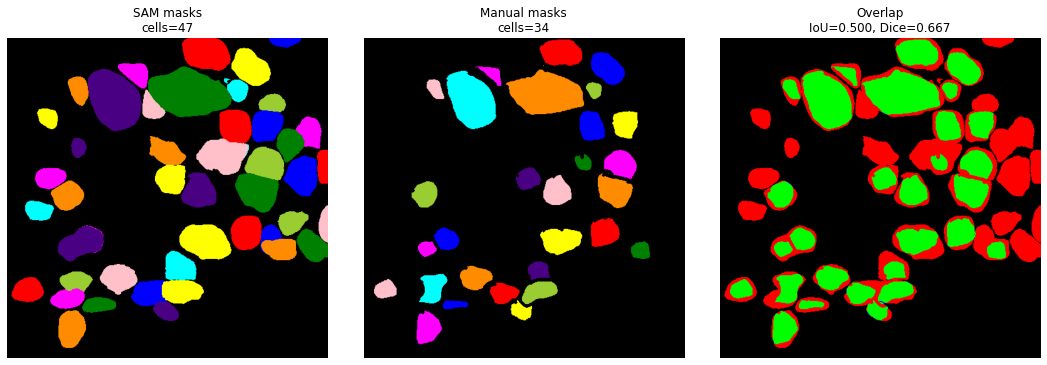

671485s1d20250728 | SAM cells=25 | Manual cells=20 | IoU=0.2989 | Dice=0.4603


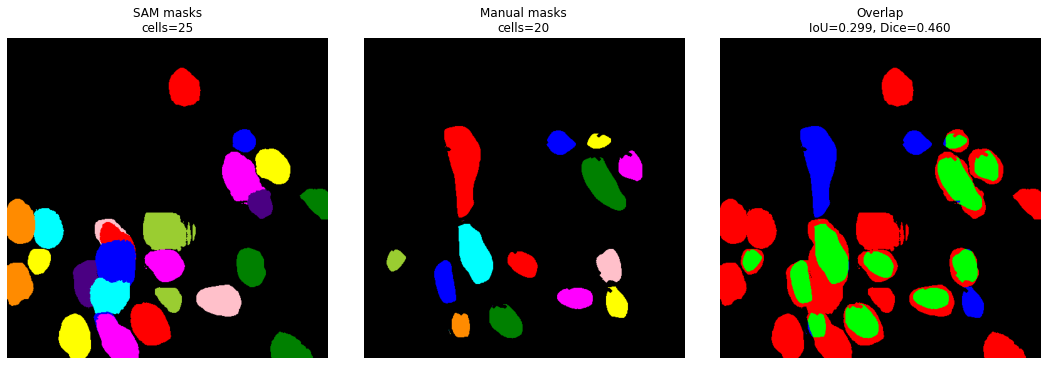

671485s2d20250728 | SAM cells=17 | Manual cells=22 | IoU=0.5668 | Dice=0.7235


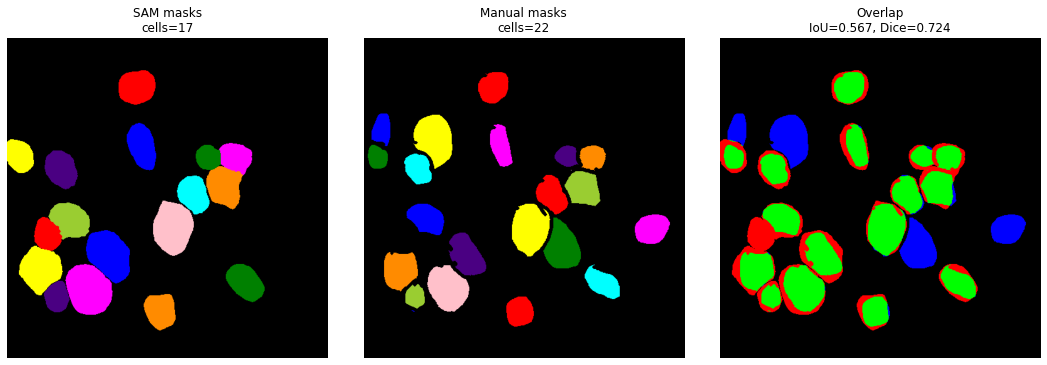

671486s1d20250728 | SAM cells=57 | Manual cells=47 | IoU=0.4474 | Dice=0.6183


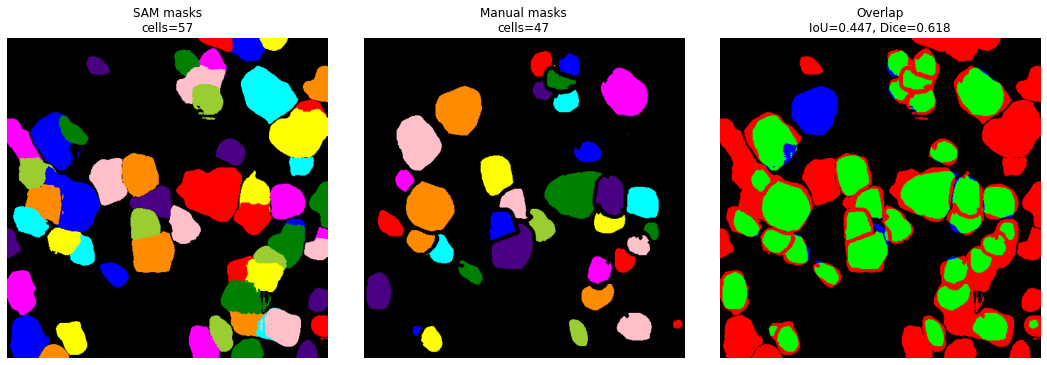

671488s1d20250326 | SAM cells=44 | Manual cells=38 | IoU=0.5121 | Dice=0.6773


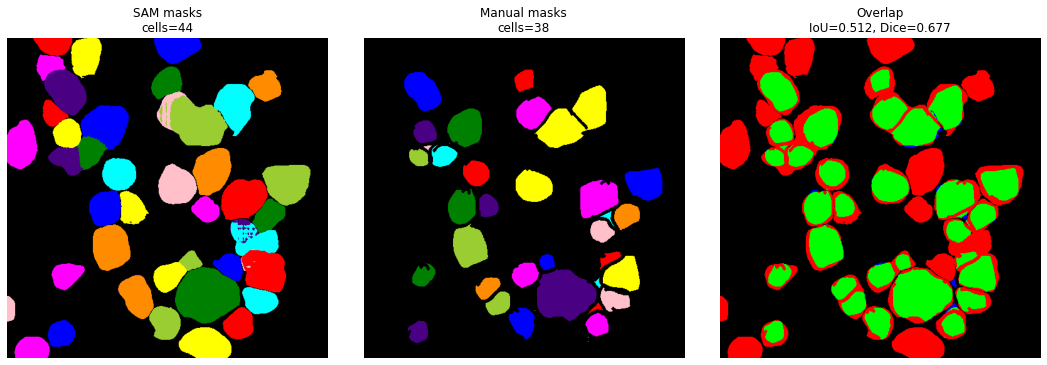

In [6]:
#COMPARING ALL THE MASKS PRINTING AND SAVING THE RESULTS 
results = []

for sam_fp in sam_files:
    base = sam_base(sam_fp)

    if base not in manual_map:
        print("No manual match for:", sam_fp.name)
        continue

    manual_fp = manual_map[base]

    sam_masks = tifffile.imread(sam_fp)
    manual_masks = tifffile.imread(manual_fp)

    if sam_masks.shape != manual_masks.shape:
        print(f"Shape mismatch for {base}: {sam_masks.shape} vs {manual_masks.shape}")
        continue

    iou, dice, sam_bin, manual_bin = compute_metrics(sam_masks, manual_masks)

    sam_cells = int(sam_masks.max())
    manual_cells = int(manual_masks.max())

    print(f"{base} | SAM cells={sam_cells} | Manual cells={manual_cells} | IoU={iou:.4f} | Dice={dice:.4f}")

    results.append([base, sam_cells, manual_cells, float(iou), float(dice)])

    # build comparison image
    comparison = np.zeros((*sam_masks.shape, 3), dtype=np.uint8)
    comparison[np.logical_and(sam_bin, manual_bin)] = [0, 255, 0]   # overlap = green
    comparison[np.logical_and(sam_bin, ~manual_bin)] = [255, 0, 0]  # SAM only = red
    comparison[np.logical_and(~sam_bin, manual_bin)] = [0, 0, 255]  # manual only = blue

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(label2rgb(sam_masks, bg_label=0))
    plt.title(f"SAM masks\ncells={sam_cells}")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(label2rgb(manual_masks, bg_label=0))
    plt.title(f"Manual masks\ncells={manual_cells}")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(comparison)
    plt.title(f"Overlap\nIoU={iou:.3f}, Dice={dice:.3f}")
    plt.axis("off")

    plt.tight_layout()

    out_png = results_dir / f"{base}_comparison.png"
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

In [7]:
out_csv = results_dir / "sam_vs_manual_results.csv"

with open(out_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["image", "sam_cells", "manual_cells", "pixel_iou", "pixel_dice"])
    writer.writerows(results)

print("Saved CSV:", out_csv)

Saved CSV: /scratch/user/s4906996/Cellpose SAM/sam_manual_comparison_results/sam_vs_manual_results.csv


In [8]:
ious = [r[3] for r in results]
dices = [r[4] for r in results]

print("Total images compared:", len(results))
print("Mean IoU:", np.mean(ious) if ious else "NA")
print("Mean Dice:", np.mean(dices) if dices else "NA")

Total images compared: 16
Mean IoU: 0.4582830662046011
Mean Dice: 0.6252859651981061
